# Generate_Data_v2.4.3

本 notebook 基于 `Generate_Data_v2.4.ipynb` 扩展，目标是：

1. 解释 GP 在生成模型中的位置与作用。
2. 总结当前版本的计算逻辑与参数设置，尤其是 DDM 参数 `v`、`a`、`t0`、`z`。
3. 保留原有统计和图表，同时补充 `Self / Stranger` 条件下 `v`、`a` 的详细可视化。

说明：这里尽量保持 v2.4 的核心生成逻辑不变，新增内容以解释、汇总和可视化为主。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from scipy.special import expit as sigmoid

# 路径配置：基于 notebook 所在目录回溯到项目根目录
BASE_DIR = Path.cwd().parent.parent
OUT_DIR = BASE_DIR / "2_Data" / "Generate_Data" / "Generate_Data_v2.4.3_checks"
FIG_DIR = BASE_DIR / "3_Figures" / "Generate_Data_v2.4.3_checks"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"数据保存目录: {OUT_DIR}")
print(f"图表保存目录: {FIG_DIR}")

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

数据保存目录: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Generate_Data_v2.4.3_checks
图表保存目录: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Generate_Data_v2.4.3_checks


## 一、GP 在这个生成模型中的位置和作用

### 1. GP 所在的位置
本模型不是“纯 GP”生成，而是一个 **S2 机制函数 + GP 修正项 + DDM 仿真** 的混合结构：

`(P, T, W) -> S2 规则函数 -> v_s2, a_s2`

`(P, T, W) -> 归一化 -> GP -> v_gp, a_gp`

`v_mix = w_gp * v_gp + (1 - w_gp) * v_s2`

`a_mix = w_gp * a_gp + (1 - w_gp) * a_s2`

`加入 trial noise -> v_final, a_final -> DDM -> RT, response`

### 2. GP 的核心作用
- GP 不是直接替代 DDM，而是用于给 `v` 和 `a` 提供一个 **非线性、平滑、可泛化** 的数据驱动修正项。
- `S2` 部分负责写入你预设的心理学机制，例如：`Self` 比 `Stranger` 有更高的漂移率、总时间 `M=T+W` 会影响边界宽度。
- `GP` 部分负责补足规则函数没有显式写出来的复杂形状，让参数面不只是单调 Sigmoid，而可以呈现局部弯曲与残差结构。

### 3. 在 v2.4 中 GP 的具体实现特点
- 输入是归一化后的 `P/T/W`：`normalize_PTW_to_unit(P, T, W)`。
- 输出是两套参数预测：`gp_v` 对应漂移率，`gp_a` 对应边界。
- 核函数是 `RBF + WhiteKernel`，意味着假设参数面是平滑变化的，同时允许少量噪声。
- 当前训练数据 `X_train, Y_v, Y_a` 是模拟构造出来的，不是真实数据拟合结果，因此这里的 GP 更像是一个“灵活残差层”或“形状先验层”。

### 4. 一个关键细节
类 `HybridDDMParameterGenerator.predict_params()` 内部虽然返回了 `t0=0.2` 和 `z=2/a`，但在真正进入 DDM 仿真前，代码又把起点重设为 `z_final = a_final / 2.0`。因此：

- **实际参与 DDM 仿真的 `z` 是边界中点**，即相对对称起点。
- `predict_params()` 返回的 `z=2/a` 在当前生成流程中并没有真正被使用。

这个点在解释参数时需要单独说明，否则容易把“预测值”和“最终用于仿真的值”混淆。

In [2]:
# Hybrid GP generator
class HybridDDMParameterGenerator:
    def __init__(self, w=0.5):
        self.w = w
        kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-5)
        self.gp_v = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
        self.gp_a = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
        self.beta_v = np.array([0.01, 0.02, -0.01])
        self.beta_a = np.array([0.005, -0.01, 0.015])

    def sigmoid_part(self, X, beta):
        return sigmoid(X @ beta)

    def fit_gp(self, X, Y_v, Y_a):
        self.gp_v.fit(X, Y_v)
        self.gp_a.fit(X, Y_a)

    def predict_params(self, X):
        sig_v = self.sigmoid_part(X, self.beta_v)
        sig_a = self.sigmoid_part(X, self.beta_a)
        gp_v = self.gp_v.predict(X)
        gp_a = self.gp_a.predict(X)
        v = self.w * sig_v + (1 - self.w) * gp_v
        a = self.w * sig_a + (1 - self.w) * gp_a
        t0 = np.full(len(v), 0.2)
        z = 2 / a
        return v, a, t0, z

# S2 辅助函数
def k_P(P, k_min=0.01, k_max=0.15, gamma=0.1, P0=32):
    return k_min + (k_max - k_min) / (1 + np.exp(-gamma * (P - P0)))


def v_P_Function(P, P1=4, k_min=0.01, k_max=0.15, gamma=0.1, P0=32):
    k = k_P(P, k_min, k_max, gamma, P0)
    return 1 / (1 + np.exp(-k * (P - P1)))


def compute_v_s2(T, P, condition_key, alaph1=1.5, alaph2=-0.4, gamma=0.2):
    T_0 = 100
    k_T = 0.01
    v_T = 1 / (1 + np.exp(-k_T * (T - T_0)))
    v_P = v_P_Function(P=P, P1=4, k_min=0.1, k_max=0.05, gamma=gamma, P0=32)
    v_0 = v_T * v_P * 3
    if condition_key == 1:
        v_1 = v_0 * (1 + alaph1)
    else:
        v_1 = v_0 * (1 + alaph2)
    return v_1


def compute_a_s2(M, beta1=0.2, beta2=0, k=0.01, M_0=600):
    a_0 = 1 / (1 + np.exp(-k * (M - M_0))) * 3
    if M > 600:
        a_1 = a_0 * (1 + beta1)
    else:
        a_1 = a_0 * (1 + beta2)
    return a_1


def normalize_PTW_to_unit(P, T, W):
    P_norm = (P - 75.0) / 75.0
    T_norm = (T - 305.0) / 295.0
    W_norm = (W - 850.0) / 650.0
    return P_norm, T_norm, W_norm

# DDM Euler 仿真
def simulate_ddm_euler(v, a, z, t0, dt=0.001, max_time_s=2.0):
    x = float(z)
    time = 0.0
    max_steps = int(max_time_s / dt)
    for _ in range(max_steps):
        dx = v * dt + np.sqrt(dt) * np.random.randn()
        x += dx
        time += dt
        if x >= a:
            return t0 + time, 1
        if x <= 0:
            return t0 + time, 0
    return np.nan, np.nan

# 生成器
def generate_dataset_s2(n_subjects=50, trials_per_sub=60, w_gp=0.5, v_noise=1.0, a_noise=0.5, save_path=None, seed=None):
    if seed is not None:
        np.random.seed(seed)
    gen = HybridDDMParameterGenerator(w=w_gp)
    X_train = np.random.uniform(-1, 1, size=(50, 3))
    Y_v = np.sin(X_train[:, 0]) * 0.5 + 0.1 * np.random.randn(50)
    Y_a = 1.5 + 0.3 * np.cos(X_train[:, 1]) + 0.05 * np.random.randn(50)
    gen.fit_gp(X_train, Y_v, Y_a)

    rows = []
    for subj in range(1, n_subjects + 1):
        T = np.random.randint(10, 600)
        P = np.random.randint(0, 150)
        W = np.random.randint(200, 1500)
        M = T + W
        a_s2 = compute_a_s2(M)
        while a_s2 <= 0:
            T = np.random.randint(10, 600)
            W = np.random.randint(200, 1500)
            M = T + W
            a_s2 = compute_a_s2(M)

        trials_per_condition = trials_per_sub // 2
        if trials_per_sub % 2 != 0:
            trials_per_condition += 1

        for condition_key in range(2):
            label = 'self' if condition_key == 1 else 'stranger'
            trial_count = 0
            while trial_count < trials_per_condition:
                v_s2 = compute_v_s2(T, P, condition_key)
                Pn, Tn, Wn = normalize_PTW_to_unit(P, T, W)
                X = np.array([[Pn, Tn, Wn]])
                v_gp, a_gp, t0_arr, z_arr = gen.predict_params(X)

                v_mix = w_gp * v_gp[0] + (1 - w_gp) * v_s2
                a_mix = w_gp * a_gp[0] + (1 - w_gp) * a_s2

                v_final = np.random.normal(v_mix, v_noise)
                a_final = np.random.normal(a_mix, a_noise)
                if a_final <= 0:
                    a_final = max(0.1, a_mix)

                z_final = a_final / 2.0
                RT, resp = simulate_ddm_euler(v_final, a_final, z_final, 0.2)

                if np.isnan(RT):
                    RT = (T + W) * 0.001
                    response = 0
                else:
                    response = 1 if resp == 1 else 2

                rows.append({
                    'subject': subj,
                    'trial': trial_count + 1,
                    'P': P,
                    'T': T,
                    'W': W,
                    'M': M,
                    'label': label,
                    'v': v_final,
                    'a': a_final,
                    't0': 0.2,
                    'z': z_final,
                    'RT': RT,
                    'response': response,
                    'v_s2': v_s2,
                    'a_s2': a_s2,
                    'v_gp_raw': v_gp[0],
                    'a_gp_raw': a_gp[0],
                    'v_mix': v_mix,
                    'a_mix': a_mix,
                })
                trial_count += 1

    df = pd.DataFrame(rows)
    if save_path is None:
        save_path = OUT_DIR / 'gp_ddm_v2.4.2_small.csv'
    else:
        save_path = Path(save_path)
    df.to_csv(save_path, index=False)
    return df, gen

## 二、这个版本的计算逻辑与参数设置

### 1. 计算流程
1. 对每个被试随机抽取实验设计变量 `P`、`T`、`W`，并计算 `M = T + W`。
2. 用 `compute_v_s2()` 生成机制层漂移率 `v_s2`。
   - `T` 越大，`v_T` 越高。
   - `P` 通过练习次数函数 `v_P_Function()` 调节。
   - `condition_key=1` 时（`Self`）乘以 `1 + alaph1 = 2.5`。
   - `condition_key=0` 时（`Stranger`）乘以 `1 + alaph2 = 0.6`。
3. 用 `compute_a_s2()` 生成机制层边界 `a_s2`。
   - 先由 `M=T+W` 经过 Sigmoid 映射为 `a_0`。
   - 当 `M > 600` 时，再乘 `(1 + beta1) = 1.2`；否则乘 `(1 + beta2) = 1.0`。
4. 将 `P/T/W` 归一化后输入 GP，得到 `v_gp_raw` 与 `a_gp_raw`。
5. 按权重 `w_gp` 混合机制层与 GP 层：
   - `v_mix = w_gp * v_gp_raw + (1 - w_gp) * v_s2`
   - `a_mix = w_gp * a_gp_raw + (1 - w_gp) * a_s2`
6. 再加入试次噪声：
   - `v_final ~ Normal(v_mix, v_noise)`
   - `a_final ~ Normal(a_mix, a_noise)`
7. 设置 `z_final = a_final / 2`，`t0 = 0.2`，进入 DDM Euler 仿真，输出 `RT` 和 `response`。

### 2. DDM 参数解释
- `v`：漂移率。证据积累朝正确边界推进的平均速度。这里主要由 `T/P/condition` 决定，并经 GP 和噪声进一步修正。
- `a`：边界分离。值越大，决策越谨慎，通常 RT 更长。这里主要由总时长 `M=T+W` 决定，并经 GP 和噪声修正。
- `t0`：非决策时长。在当前代码中固定为 `0.2s`，不随条件变化。
- `z`：起点位置。当前真正进入仿真的值是 `a/2`，也就是位于上下边界正中间，不带先验偏置。

### 3. 当前版本的关键默认参数
- `w_gp = 0.5`：机制层与 GP 层各占一半。
- `v_noise = 1.0`：漂移率试次噪声较大，能明显拉开 trial-level 波动。
- `a_noise = 0.5`：边界试次噪声中等。
- `alaph1 = 1.5`：`Self` 的漂移率增强幅度。
- `alaph2 = -0.4`：`Stranger` 的漂移率削弱幅度。
- `beta1 = 0.2, beta2 = 0`：`M > 600` 时放大边界。
- `t0 = 0.2`：固定非决策时长。
- `dt = 0.001, max_time_s = 2.0`：Euler 仿真的时间精度与最大决策窗口。

### 4. 一个解释上需要特别注意的点
`Self / Stranger` 在当前代码里**直接作用于 `v`，并不直接作用于 `a`**。因此如果图中出现 `a` 的条件差异，那主要来自：
- GP 混合后的间接差异；
- trial-level 噪声；
- 不同条件样本在随机抽样上的波动；
而不是 `compute_a_s2()` 中的显式条件效应。

In [3]:
# 生成数据集
# 如果你想先快速检查，可以把 n_subjects 改成 100 或 200
df, gen = generate_dataset_s2(
    n_subjects=2000,
    trials_per_sub=60,
    w_gp=0.5,
    seed=42,
)

out_csv = OUT_DIR / 'gp_ddm_v2.4.3_large.csv'
df.to_csv(out_csv, index=False)
print('Saved CSV to', out_csv)

# 基础整理
df = df.copy()
df['RT_ms'] = df['RT'] * 1000
print('\nOverall trials:', len(df))
print('RT mean (s):', df['RT'].mean())
print('RT median (s):', df['RT'].median())
print('Percent RT <= 2s:', (df['RT'] <= 2.0).mean())
print('Proportion upper (1):', (df['response'] == 1).mean())
print('Proportion lower (2):', (df['response'] == 2).mean())

c:\Users\蔡振辛\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\蔡振辛\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Saved CSV to d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Generate_Data_v2.4.3_checks\gp_ddm_v2.4.3_large.csv

Overall trials: 120000
RT mean (s): 0.7648892833333282
RT median (s): 0.631
Percent RT <= 2s: 0.9857833333333333
Proportion upper (1): 0.7949833333333334
Proportion lower (2): 0.14666666666666667


In [4]:
# 参数与 SPE 汇总
mean_by_label = df.groupby('label')[['RT', 'RT_ms', 'v', 'a', 't0', 'z', 'v_s2', 'a_s2', 'v_gp_raw', 'a_gp_raw', 'v_mix', 'a_mix']].agg(['mean', 'std', 'median'])
print('不同条件的参数汇总：')
display(mean_by_label.round(4))

subj_means = (
    df.groupby(['subject', 'label'])[['RT_ms', 'v', 'a', 'z']]
      .mean()
      .reset_index()
)

subj_rt = subj_means.pivot(index='subject', columns='label', values='RT_ms').dropna()
subj_rt['SPE_ms'] = subj_rt['self'] - subj_rt['stranger']

mean_spe = subj_rt['SPE_ms'].mean()
sd_spe = subj_rt['SPE_ms'].std(ddof=1)
cohens_d = mean_spe / sd_spe if sd_spe > 0 else np.nan

print('\nMean RT by label (s):')
print(df.groupby('label')['RT'].mean().round(4))
print('\nMean SPE (ms):', round(mean_spe, 4))
print('SD SPE (ms):', round(sd_spe, 4))
print("Cohen's d (paired):", round(cohens_d, 4))

anchors = np.array([
    normalize_PTW_to_unit(r['P'], r['T'], r['W'])
    for _, r in df.groupby('subject').first().iterrows()
])
_, std_v = gen.gp_v.predict(anchors, return_std=True)
_, std_a = gen.gp_a.predict(anchors, return_std=True)
print('\nGP predictive std (v) - mean:', round(float(np.mean(std_v)), 4))
print('GP predictive std (v) - std :', round(float(np.std(std_v)), 4))
print('GP predictive std (a) - mean:', round(float(np.mean(std_a)), 4))
print('GP predictive std (a) - std :', round(float(np.std(std_a)), 4))

不同条件的参数汇总：


RT                    RT_ms                        v          \
            mean     std median      mean       std median    mean     std   
label                                                                        
self      0.6219  0.3318  0.525  621.8521  331.7927  525.0  2.8039  1.3103   
stranger  0.9079  0.4721  0.805  907.9264  472.1170  805.0  0.7605  1.0157   

                       a  ... v_gp_raw a_gp_raw                   v_mix  \
          median    mean  ...   median     mean     std  median    mean   
label                     ...                                             
self      2.8598  2.1624  ...   0.2141   1.1256  0.0014  1.1257  2.8038   
stranger  0.7613  2.1600  ...   0.2141   1.1256  0.0014  1.1257  0.7543   

                           a_mix                  
             std  median    mean     std  median  
label                                             
self      0.8467  3.0743  2.1577  0.4283  2.3555  
stranger  0.2038  0.8189  2.1577  0.4283  2.3555  

[2 rows x 36 columns]


Mean RT by label (s):
label
self        0.6219
stranger    0.9079
Name: RT, dtype: float64

Mean SPE (ms): -286.0743
SD SPE (ms): 169.2218
Cohen's d (paired): -1.6905

GP predictive std (v) - mean: 0.2585
GP predictive std (v) - std : 0.0
GP predictive std (a) - mean: 0.0636
GP predictive std (a) - std : 0.0


## 三、可视化

下面这部分保留原版的 RT 与 SPE 图，同时新增两类更细的参数图：

- `Self / Stranger` 的 `v`、`a` 分布对比；
- 受试者平均参数层面的配对比较，更接近分析 SPE 时的被试水平视角。

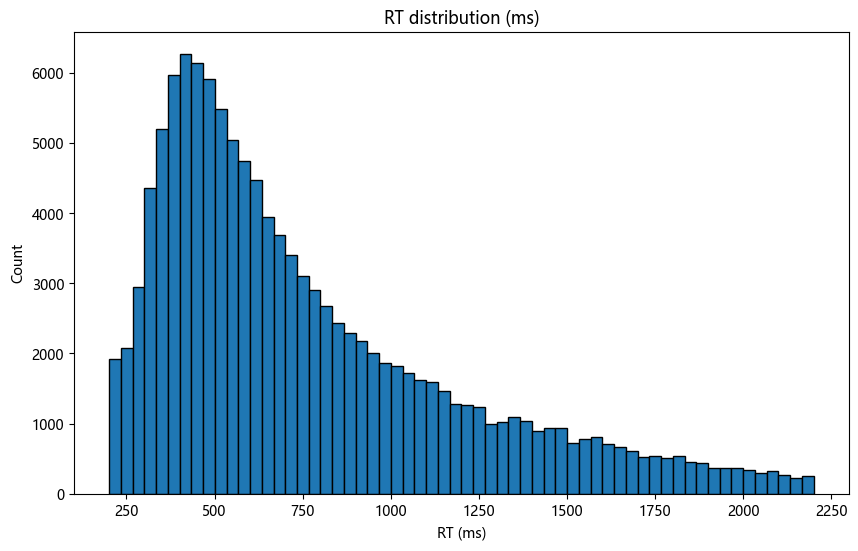

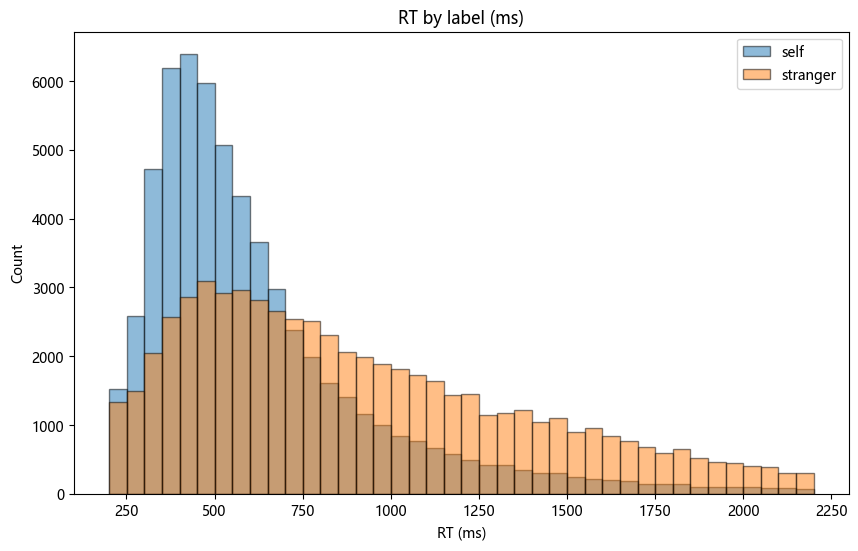

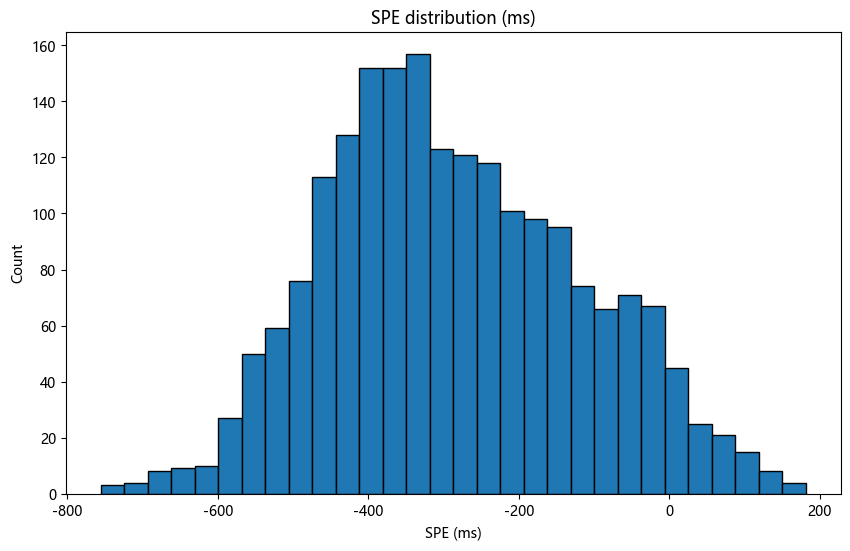

In [5]:
# 1. 原有可视化：RT 分布、按条件 RT、SPE 分布
plt.figure(figsize=(10, 6))
plt.hist(df['RT_ms'], bins=60, edgecolor='black')
plt.title('RT distribution (ms)')
plt.xlabel('RT (ms)')
plt.ylabel('Count')
plt.savefig(FIG_DIR / 'RT_distribution_v2.4.3.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
for label in ['self', 'stranger']:
    subset = df[df['label'] == label]['RT_ms']
    plt.hist(subset, bins=40, alpha=0.5, label=label, edgecolor='black')
plt.legend()
plt.title('RT by label (ms)')
plt.xlabel('RT (ms)')
plt.ylabel('Count')
plt.savefig(FIG_DIR / 'RT_by_label_v2.4.3.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(subj_rt['SPE_ms'].dropna(), bins=30, edgecolor='black')
plt.title('SPE distribution (ms)')
plt.xlabel('SPE (ms)')
plt.ylabel('Count')
plt.savefig(FIG_DIR / 'SPE_dist_v2.4.3.png', dpi=200, bbox_inches='tight')
plt.show()

C:\Users\蔡振辛\AppData\Local\Temp\ipykernel_76680\14866958.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  v_result = axes[1, 0].boxplot(v_box, labels=order, patch_artist=True)
C:\Users\蔡振辛\AppData\Local\Temp\ipykernel_76680\14866958.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a_result = axes[1, 1].boxplot(a_box, labels=order, patch_artist=True)


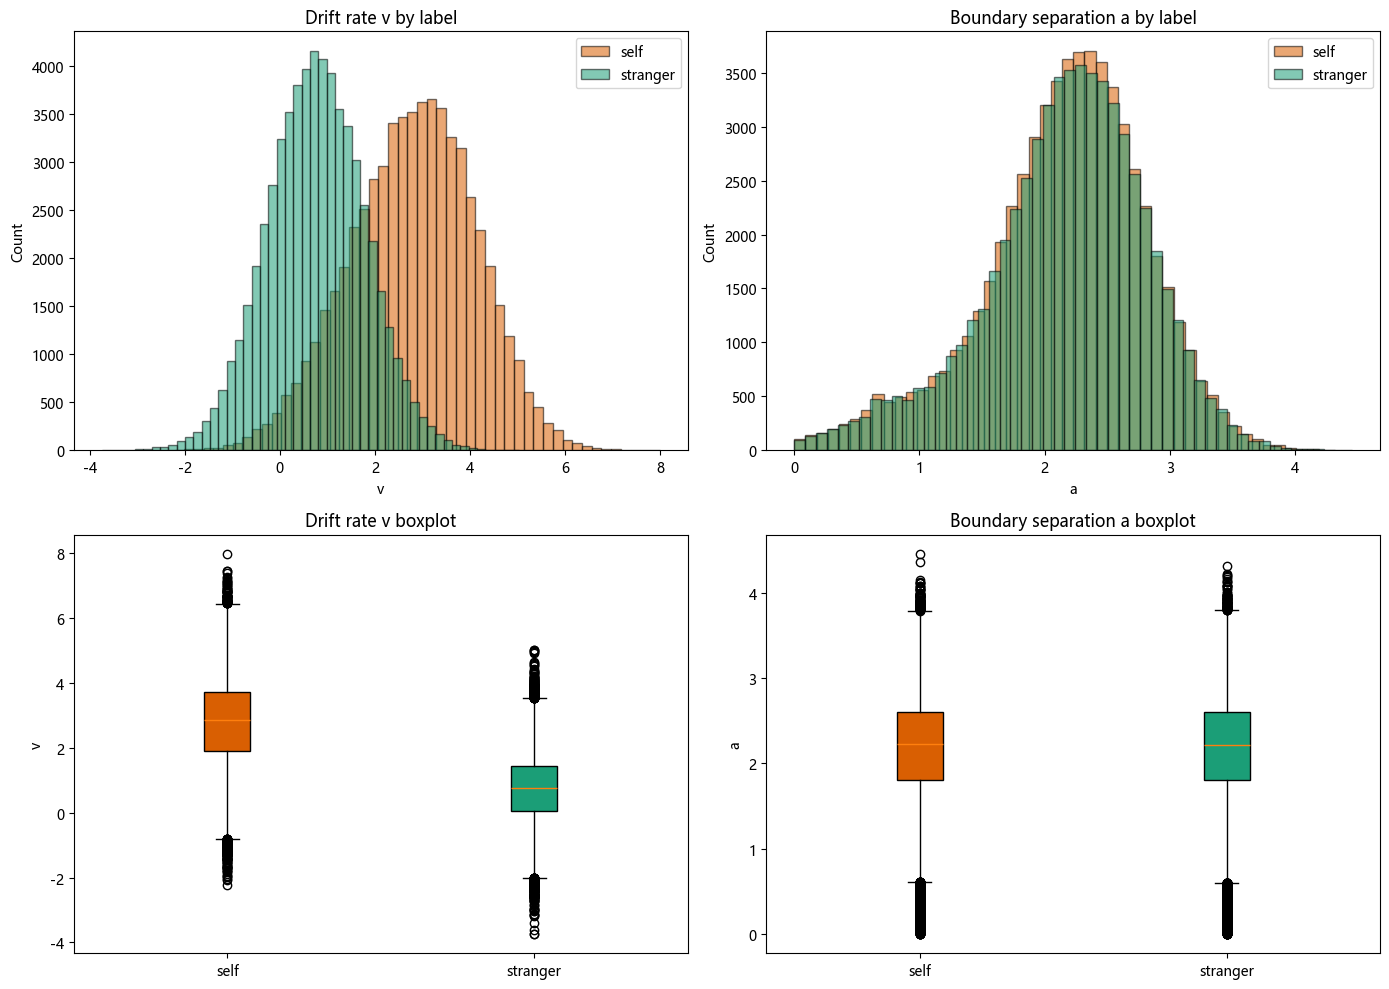

In [6]:
# 2. 新增：Self / Stranger 条件下 v、a 的 trial-level 分布比较
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {'self': '#d95f02', 'stranger': '#1b9e77'}
order = ['self', 'stranger']

# v 的直方图
for label in order:
    axes[0, 0].hist(
        df.loc[df['label'] == label, 'v'],
        bins=50,
        alpha=0.55,
        label=label,
        color=colors[label],
        edgecolor='black'
    )
axes[0, 0].set_title('Drift rate v by label')
axes[0, 0].set_xlabel('v')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()

# a 的直方图
for label in order:
    axes[0, 1].hist(
        df.loc[df['label'] == label, 'a'],
        bins=50,
        alpha=0.55,
        label=label,
        color=colors[label],
        edgecolor='black'
    )
axes[0, 1].set_title('Boundary separation a by label')
axes[0, 1].set_xlabel('a')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

# v 的箱线图
v_box = [df.loc[df['label'] == label, 'v'].values for label in order]
v_result = axes[1, 0].boxplot(v_box, labels=order, patch_artist=True)
for patch, label in zip(v_result['boxes'], order):
    patch.set_facecolor(colors[label])
axes[1, 0].set_title('Drift rate v boxplot')
axes[1, 0].set_ylabel('v')

# a 的箱线图
a_box = [df.loc[df['label'] == label, 'a'].values for label in order]
a_result = axes[1, 1].boxplot(a_box, labels=order, patch_artist=True)
for patch, label in zip(a_result['boxes'], order):
    patch.set_facecolor(colors[label])
axes[1, 1].set_title('Boundary separation a boxplot')
axes[1, 1].set_ylabel('a')

plt.tight_layout()
plt.savefig(FIG_DIR / 'v_a_by_label_trial_level_v2.4.3.png', dpi=220, bbox_inches='tight')
plt.show()

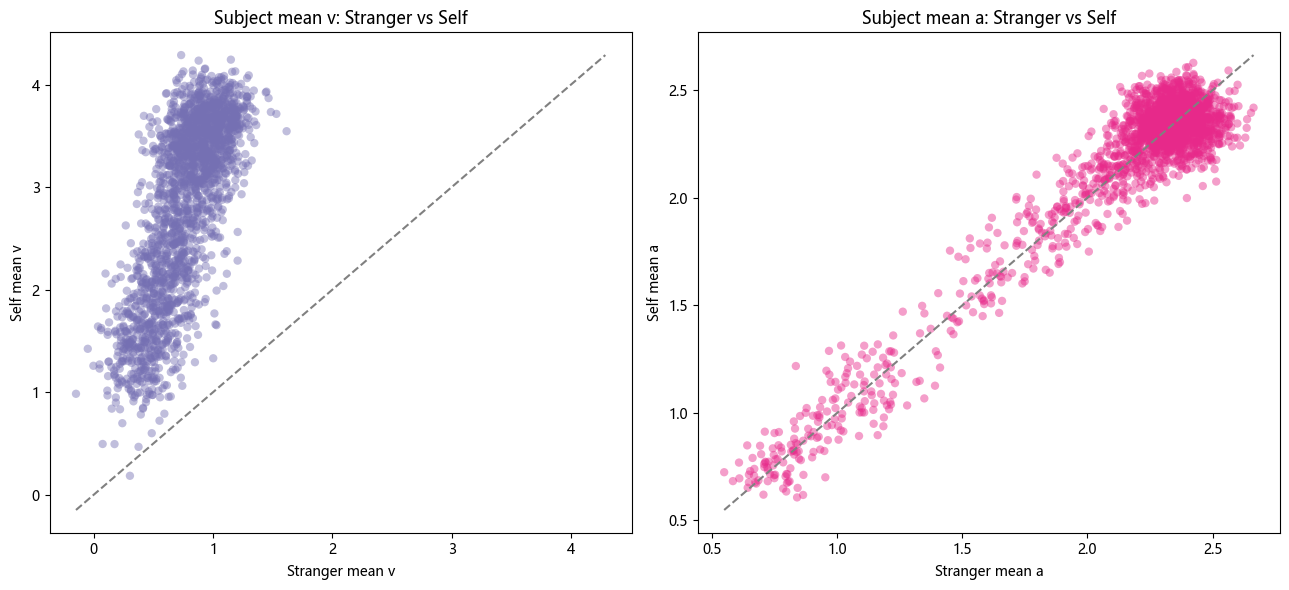

Figures saved to d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Generate_Data_v2.4.3_checks


In [7]:
# 3. 新增：受试者平均参数的配对比较，更直观看 Self / Stranger 的差异方向
subj_param = (
    df.groupby(['subject', 'label'])[['v', 'a']]
      .mean()
      .reset_index()
)

subj_v = subj_param.pivot(index='subject', columns='label', values='v').dropna()
subj_a = subj_param.pivot(index='subject', columns='label', values='a').dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# v: 配对散点
axes[0].scatter(subj_v['stranger'], subj_v['self'], alpha=0.45, color='#7570b3', edgecolor='none')
line_min_v = min(subj_v['stranger'].min(), subj_v['self'].min())
line_max_v = max(subj_v['stranger'].max(), subj_v['self'].max())
axes[0].plot([line_min_v, line_max_v], [line_min_v, line_max_v], '--', color='gray')
axes[0].set_title('Subject mean v: Stranger vs Self')
axes[0].set_xlabel('Stranger mean v')
axes[0].set_ylabel('Self mean v')

# a: 配对散点
axes[1].scatter(subj_a['stranger'], subj_a['self'], alpha=0.45, color='#e7298a', edgecolor='none')
line_min_a = min(subj_a['stranger'].min(), subj_a['self'].min())
line_max_a = max(subj_a['stranger'].max(), subj_a['self'].max())
axes[1].plot([line_min_a, line_max_a], [line_min_a, line_max_a], '--', color='gray')
axes[1].set_title('Subject mean a: Stranger vs Self')
axes[1].set_xlabel('Stranger mean a')
axes[1].set_ylabel('Self mean a')

plt.tight_layout()
plt.savefig(FIG_DIR / 'v_a_subject_pair_compare_v2.4.3.png', dpi=220, bbox_inches='tight')
plt.show()

print('Figures saved to', FIG_DIR)

## 四、设计变量 P / T / W 的影响可视化

下面这部分专门回答一个更结构化的问题：实验设计变量 `P`、`T`、`W` 分别如何影响模型参数与行为输出。

- 参数层面：观察 `v`、`a`、`t0`、`z` 随 `P / T / W` 的变化。
- 行为层面：观察 `RT`、`ACC` 随 `P / T / W` 的变化。

这里使用 **分箱后的均值曲线** 来可视化整体趋势。由于当前代码中 `t0` 固定为 `0.2`，因此它的曲线应该基本是一条水平线；这一结果本身也有解释价值。

In [8]:
# 4. 新增：构造设计变量效应分析所需的数据与辅助函数

df_effect = df.copy()
df_effect['ACC'] = (df_effect['response'] == 1).astype(int)
df_effect['t'] = df_effect['t0']

def summarize_by_bins(data, x_col, y_col, bins=8):
    temp = data[[x_col, y_col]].dropna().copy()
    temp['bin'] = pd.cut(temp[x_col], bins=bins, include_lowest=True, duplicates='drop')
    summary = (
        temp.groupby('bin', observed=False)
            .agg(
                x_mean=(x_col, 'mean'),
                y_mean=(y_col, 'mean'),
                y_std=(y_col, 'std'),
                n=(y_col, 'size')
            )
            .reset_index(drop=True)
    )
    summary['y_sem'] = summary['y_std'] / np.sqrt(summary['n'].clip(lower=1))
    return summary


def plot_design_effect_grid(data, x_vars, metrics, bins=8, figsize=(18, 14), title=None, save_path=None):
    fig, axes = plt.subplots(len(metrics), len(x_vars), figsize=figsize, sharex=False, sharey='row')

    if len(metrics) == 1 and len(x_vars) == 1:
        axes = np.array([[axes]])
    elif len(metrics) == 1:
        axes = np.array([axes])
    elif len(x_vars) == 1:
        axes = np.array([[ax] for ax in axes])

    colors = {
        'P': '#1b9e77',
        'T': '#d95f02',
        'W': '#7570b3',
    }

    for row_idx, metric in enumerate(metrics):
        for col_idx, x_var in enumerate(x_vars):
            ax = axes[row_idx, col_idx]
            summary = summarize_by_bins(data, x_var, metric, bins=bins)
            ax.plot(summary['x_mean'], summary['y_mean'], marker='o', color=colors[x_var], linewidth=2)
            ax.fill_between(
                summary['x_mean'],
                summary['y_mean'] - summary['y_sem'],
                summary['y_mean'] + summary['y_sem'],
                color=colors[x_var],
                alpha=0.18
            )
            ax.set_xlabel(x_var)
            if col_idx == 0:
                ax.set_ylabel(metric)
            ax.set_title(f'{x_var} -> {metric}')
            ax.grid(alpha=0.25)

    if title is not None:
        fig.suptitle(title, fontsize=16, y=0.995)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=220, bbox_inches='tight')
    plt.show()

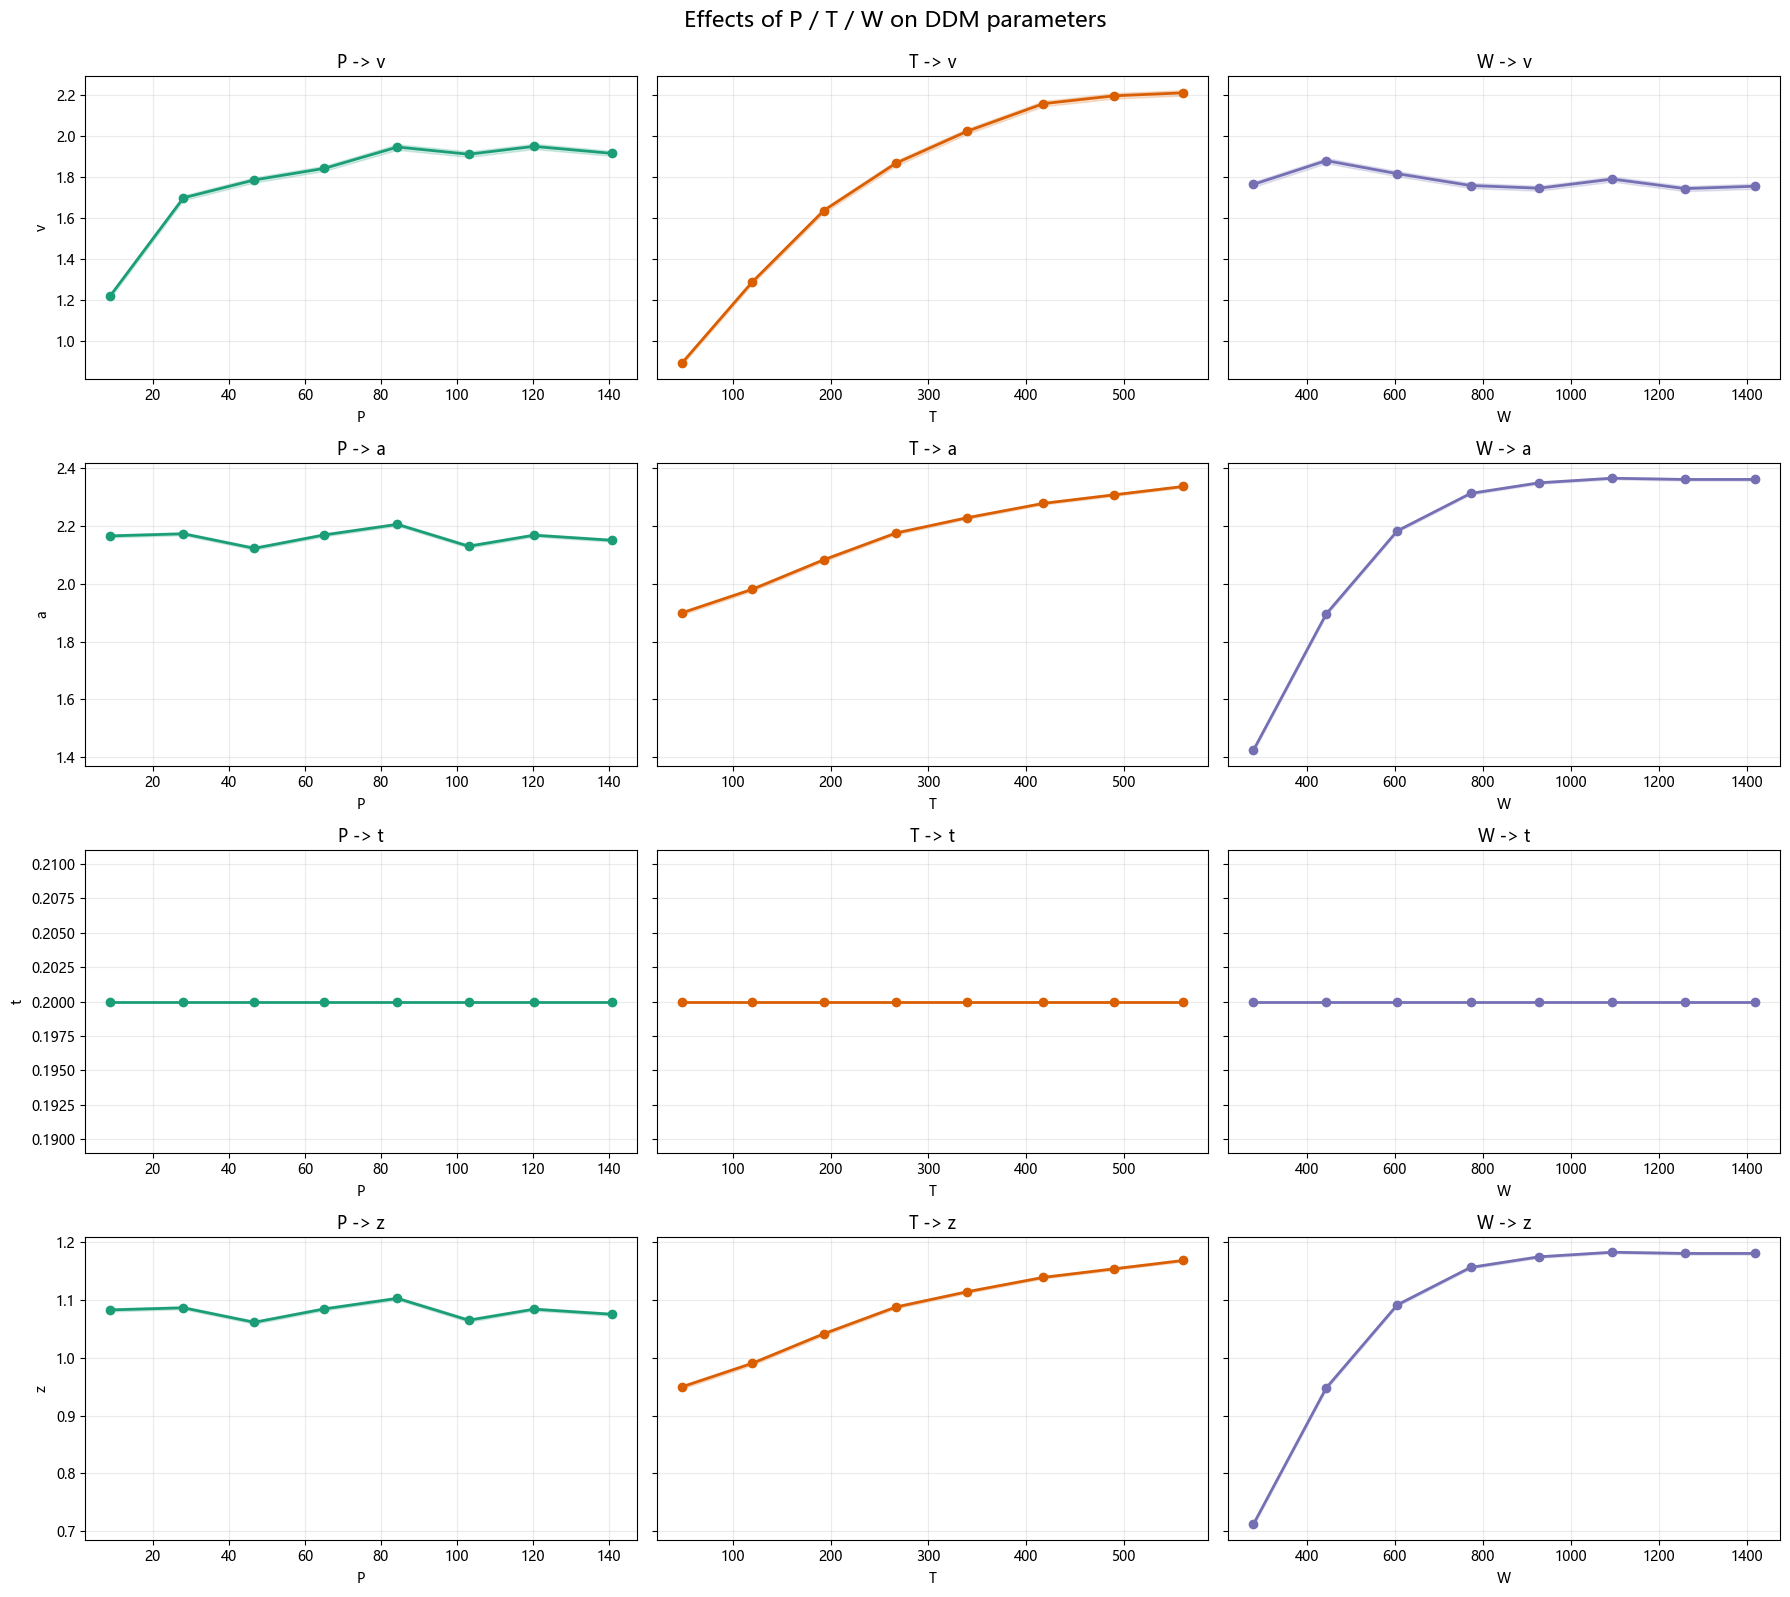

In [9]:
# 5. 新增：P / T / W 对 v、a、t、z 的影响

plot_design_effect_grid(
    data=df_effect,
    x_vars=['P', 'T', 'W'],
    metrics=['v', 'a', 't', 'z'],
    bins=8,
    figsize=(18, 16),
    title='Effects of P / T / W on DDM parameters',
    save_path=FIG_DIR / 'PTW_to_v_a_t_z_v2.4.3.png'
)

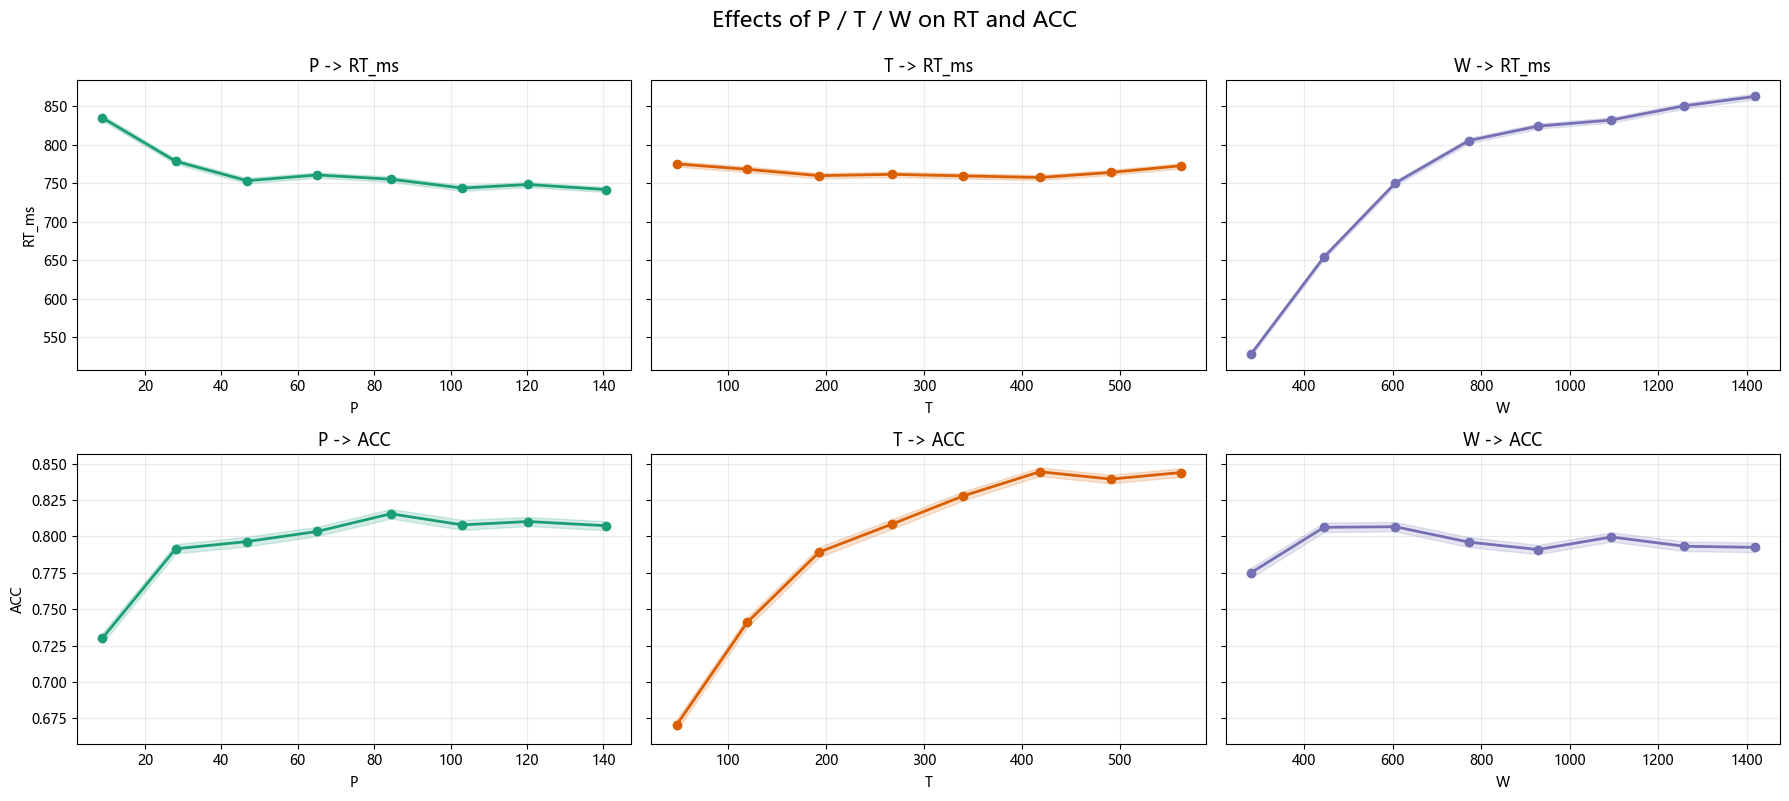

In [10]:
# 6. 新增：P / T / W 对 RT、ACC 的影响

plot_design_effect_grid(
    data=df_effect,
    x_vars=['P', 'T', 'W'],
    metrics=['RT_ms', 'ACC'],
    bins=8,
    figsize=(18, 8),
    title='Effects of P / T / W on RT and ACC',
    save_path=FIG_DIR / 'PTW_to_RT_ACC_v2.4.3.png'
)

## 五、如何解读这些 P / T / W 效应图

- `P -> v`：如果曲线整体上升，表示练习次数增加会提高漂移率，证据积累更快。
- `T -> v`：如果随刺激呈现时间增加而上升，说明更长的刺激暴露有利于信息提取。
- `W` 对 `a` 或 `RT` 的影响：通常会部分通过 `M=T+W` 的结构间接传导到边界和反应时。
- `t` 曲线近似水平是当前模型设定导致的，而不是图画错了，因为代码中 `t0` 被固定为 `0.2s`。
- `z` 会随 `a` 同步变化，因为当前真正进入仿真的设定是 `z = a / 2`。
- `ACC` 这里按当前代码约定，使用 `response == 1` 的比例表示，因此更准确地说，它反映的是上边界命中率或当前脚本下的正确反应比例。

如果你后面还想更进一步，可以继续扩展成两种版本：
- 按 `Self / Stranger` 分开画 `P / T / W -> RT / ACC` 的条件曲线；
- 直接画 2D 热图，例如 `P × T -> v`、`T × W -> RT`，这样更适合展示交互效应。

## 六、如何解读新增的 `v / a` 图

- 如果 `v` 的 `Self` 分布整体右移，说明当前版本的自我条件主要通过 **更高的证据积累速度** 产生优势，这和 `compute_v_s2()` 的设定一致。
- 如果 `a` 的两种条件差异不大，说明模型里的条件效应主要不在边界，而在漂移率；这也符合当前代码结构。
- 如果 `a` 图上仍出现少量条件差异，优先解释为 GP 混合和 trial 噪声造成的次级差异，而不是理论上专门写入的条件主效应。
- 在配对散点图中，若多数点落在对角线之上，表示 `Self > Stranger`；落在下方则表示 `Self < Stranger`。

如果你后面要把这版内容放进汇报或论文草稿，这个 notebook 已经可以直接作为“模型说明 + 参数解释 + 图表补充”的基础版本。